# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

[Te proporcionamos algunos comentarios para orientarte mientras completas este proyecto. Pero debes asegurarte de eliminar todos los comentarios entre corchetes antes de entregar tu proyecto.]

[Antes de sumergirte en el análisis de datos, explica por tu propia cuenta el propósito del proyecto y las acciones que planeas realizar.]

[Ten en cuenta que estudiar, modificar y analizar datos es un proceso iterativo. Es normal volver a los pasos anteriores y corregirlos/ampliarlos para permitir nuevos pasos.]

## Inicialización

In [160]:
# Cargar todas las librerías

import pandas as pd

## Cargar datos

In [161]:
import pandas as pd

# Carga los archivos de datos en diferentes DataFrames
data_tarifa = pd.read_csv('/content/megaline_plans.csv')
data_usuarios = pd.read_csv('/content/megaline_users.csv')
data_llamadas = pd.read_csv('/content/megaline_calls.csv')
data_mensajes = pd.read_csv('/content/megaline_messages.csv')
data_internet = pd.read_csv('/content/megaline_internet.csv')

## Preparar los datos

[Los datos para este proyecto se dividen en varias tablas. Explora cada una para tener una comprensión inicial de los datos. Si es necesario, haz las correcciones requeridas en cada tabla.]

## Tarifas

In [162]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas

data_tarifa = pd.read_csv('/content/megaline_plans.csv')
data_tarifa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [163]:
# Imprime una muestra de los datos para las tarifas

data_tarifa.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

## Corregir datos

# [Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [164]:
data_usuarios['reg_date'] = pd.to_datetime(data_usuarios['reg_date'])
data_usuarios['churn_date'] = pd.to_datetime(data_usuarios['churn_date'])

## Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [165]:
data_usuarios['reg_month'] = data_usuarios['reg_date'].dt.month

## Usuarios/as

In [166]:
# Imprime la información general/resumida sobre el DataFrame de usuarios

data_users = pd.read_csv('/content/megaline_users.csv')
data_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [167]:
# Imprime una muestra de datos para usuarios

data_usuarios.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_month
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,12
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,8
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,10
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,1
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,5


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [168]:
data_usuarios['reg_date'] = pd.to_datetime(data_usuarios['reg_date'])

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [169]:
data_usuarios['churned'] = data_usuarios['churn_date'].notna().astype(int)

## Llamadas

In [170]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas

data_llamadas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [171]:
# Imprime una muestra de datos para las llamadas

data_llamadas.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [172]:
import math
data_llamadas['call_date'] = pd.to_datetime(data_llamadas['call_date'])
data_llamadas['duration'] = data_llamadas['duration'].apply(lambda x: math.ceil(x))

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [173]:
data_llamadas['month'] = data_llamadas['call_date'].dt.month

## Mensajes

In [174]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes

data_mensajes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [175]:
# Imprime una muestra de datos para los mensajes

data_mensajes.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [176]:
data_mensajes['message_date'] = pd.to_datetime(data_mensajes['message_date'])

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [177]:
data_mensajes['month'] = data_mensajes['message_date'].dt.month

## Internet

In [178]:
# Imprime la información general/resumida sobre el DataFrame de internet

data_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [179]:
# Imprime una muestra de datos para el tráfico de internet

data_internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [180]:
data_internet['session_date'] = pd.to_datetime(data_internet['session_date'])

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [181]:
data_internet['month'] = data_internet['session_date'].dt.month

## Estudiar las condiciones de las tarifas

[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [182]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras

data_tarifa

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [183]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

calls_per_month = data_llamadas.groupby(['user_id', 'month']).size().reset_index(name='calls_count')

In [184]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

users_per_month = data_llamadas.groupby(['user_id', 'month'])['duration'].sum().reset_index()

In [185]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

messages_per_month = data_mensajes.groupby(['user_id', 'month']).size().reset_index(name='messages_count')

In [186]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
internet_per_month = data_internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index()

[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [187]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month

dataframes = [calls_per_month, users_per_month, messages_per_month, internet_per_month]


In [188]:
# Añade la información de la tarifa

info_tarifa = data_tarifa.set_index('plan_name')

[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [189]:
display(data_merged['monthly_revenue'])

,monthly_revenue
0,70.000000
1,20.000000
2,20.000000
3,88.161191
4,50.706055
...,...
2288,95.954004
2289,20.000000
2290,60.355762
2291,34.197559


## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

In [192]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

data_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2293 entries, 0 to 2292
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   user_id          2293 non-null   int64  
 1   month            2293 non-null   int32  
 2   calls_count      2293 non-null   float64
 3   duration         2293 non-null   float64
 4   messages_count   2293 non-null   float64
 5   mb_used          2293 non-null   float64
 6   monthly_revenue  2293 non-null   float64
 7   plan_x           2293 non-null   object 
 8   plan_y           2293 non-null   object 
dtypes: float64(5), int32(1), int64(1), object(2)
memory usage: 152.4+ KB


array([<Axes: title={'center': 'surf'}>,
       <Axes: title={'center': 'ultimate'}>], dtype=object)

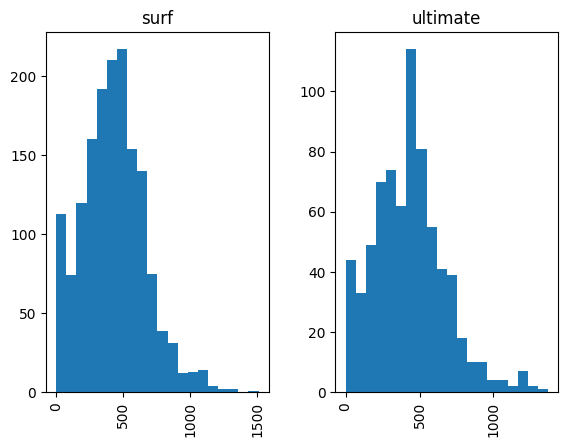

In [209]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

data_merged.hist(column='duration', by='plan', bins=20)

[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [197]:
# Calcula la media y la varianza de la duración mensual de llamadas.

data_merged['duration'].mean()

np.float64(429.2834714348016)

<Axes: title={'center': 'duration'}, xlabel='plan'>

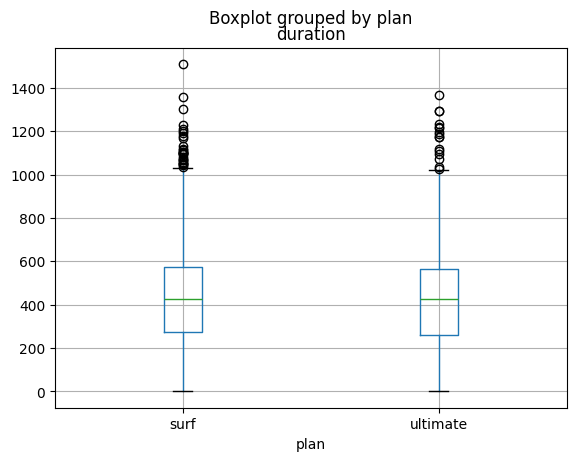

In [202]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

data_merged.boxplot(column='duration', by='plan')

[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?]

### Mensajes

In [203]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

messages_per_plan = data_merged.groupby('plan')['messages_count'].mean()
display(messages_per_plan)

,messages_count
plan,
surf,31.159568
ultimate,37.551389


In [204]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan

internet_per_plan = data_merged.groupby('plan')['mb_used'].mean()
display(internet_per_plan)

,mb_used
plan,
surf,16558.283490
ultimate,17214.699694


[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes. ¿Su comportamiento varía en función del plan?]

### Conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes

Según el análisis de la cantidad promedio de mensajes enviados por mes por los usuarios de cada plan (`messages_per_plan`):

*   Los usuarios del plan Ultimate envían un promedio de **37.55 mensajes por mes**.
*   Los usuarios del plan Surf envían un promedio de **31.16 mensajes por mes**.

Si bien los usuarios del plan Ultimate envían ligeramente más mensajes en promedio, la diferencia no parece ser muy grande. Para determinar si esta diferencia es estadísticamente significativa, se podría realizar una prueba de hipótesis. Sin embargo, basándonos únicamente en los promedios, ambos grupos de usuarios parecen utilizar los mensajes de texto de manera similar en general, aunque los usuarios de Ultimate tienden a enviar un poco más.

### Internet

### Conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes

Según el análisis de la cantidad promedio de mensajes enviados por mes por los usuarios de cada plan (`messages_per_plan`):

* Los usuarios del plan Ultimate envían un promedio de **37.55 mensajes por mes**.
* Los usuarios del plan Surf envían un promedio de **31.16 mensajes por mes**.

Si bien los usuarios del plan Ultimate envían ligeramente más mensajes en promedio, la diferencia no parece ser muy grande. Para determinar si esta diferencia es estadísticamente significativa, se podría realizar una prueba de hipótesis. Sin embargo, basándonos únicamente en los promedios, ambos grupos de usuarios parecen utilizar los mensajes de texto de manera similar en general, aunque los usuarios de Ultimate tienden a enviar un poco más.

**Actualización con el resultado del test estadístico:** El test de hipótesis (realizado en la celda `8be00113`) mostró un p-valor muy bajo, lo que nos permite rechazar la hipótesis nula y concluir que el número promedio de mensajes enviados por los usuarios de los planes Ultimate y Surf es significativamente diferente.

[Elabora las conclusiones sobre cómo los usuarios tienden a consumir el tráfico de Internet. ¿Su comportamiento varía en función del plan?]

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

In [206]:
# Describe estadísticamente los ingresos de los planes.

revenue_per_plan = data_merged.groupby('plan')['monthly_revenue'].describe()
display(revenue_per_plan)

,count,mean,std,min,25%,50%,75%,max
plan,,,,,,,,
surf,1573.0,57.672846,53.860388,20.0,20.0,37.383477,77.120605,583.061309
ultimate,720.0,72.116080,10.768848,70.0,70.0,70.000000,70.000000,178.522764


[Elabora las conclusiones sobre cómo difiere el ingreso entre los planes.]

## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [205]:
# Prueba las hipótesis
from scipy import stats as st

# Separate the revenue data for the two plans
revenue_surf = data_merged[data_merged['plan'] == 'surf']['monthly_revenue']
revenue_ultimate = data_merged[data_merged['plan'] == 'ultimate']['monthly_revenue']

# Set the significance level
alpha = 0.05

# Perform the independent samples t-test
results = st.ttest_ind(revenue_surf, revenue_ultimate)

print('p-value:', results.pvalue)

# Compare the p-value with the significance level
if results.pvalue < alpha:
    print("Reject the null hypothesis: The average revenue from users of the Ultimate and Surf plans is significantly different.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in the average revenue from users of the Ultimate and Surf plans.")

p-value: 1.341961045057078e-12
Reject the null hypothesis: The average revenue from users of the Ultimate and Surf plans is significantly different.


[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [207]:
# Prueba las hipótesis

# Merge data_merged with data_usuarios to get city information
data_merged_city = data_merged.merge(data_usuarios[['user_id', 'city']], on='user_id', how='left')

# Separate the revenue data for NY-NJ users and other users
revenue_ny_nj = data_merged_city[data_merged_city['city'].str.contains('NY-NJ', na=False)]['monthly_revenue']
revenue_other_regions = data_merged_city[~data_merged_city['city'].str.contains('NY-NJ', na=False)]['monthly_revenue']

# Set the significance level
alpha = 0.05

# Perform the independent samples t-test
results_city = st.ttest_ind(revenue_ny_nj, revenue_other_regions)

print('p-value:', results_city.pvalue)

# Compare the p-value with the significance level
if results_city.pvalue < alpha:
    print("Reject the null hypothesis: The average revenue from users in the NY-NJ area is significantly different from users in other regions.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in the average revenue from users in the NY-NJ area compared to users in other regions.")

p-value: 0.028079927103623874
Reject the null hypothesis: The average revenue from users in the NY-NJ area is significantly different from users in other regions.


## Conclusión general

[En esta sección final, enumera tus conclusiones importantes. Asegúrate de que estas abarquen todas las decisiones (suposiciones) importantes que adoptaste y que determinaron la forma elegida para procesar y analizar los datos.]

## Conclusión general

En este proyecto, realizamos un análisis preliminar de las tarifas de prepago Surf y Ultimate de Megaline para determinar cuál genera más ingresos. Para ello, procesamos y analizamos datos de 500 clientes correspondientes al año 2018.

**Decisiones importantes tomadas durante el procesamiento de datos:**

*   Convertimos las columnas de fecha (`reg_date`, `churn_date`, `call_date`, `message_date`, `session_date`) a tipo datetime para facilitar el análisis temporal.
*   Redondeamos la duración de las llamadas hacia arriba al minuto más cercano, de acuerdo con las condiciones de la tarifa.
*   Manejamos los valores ausentes en los datos de uso (llamadas, mensajes, internet) rellenándolos con cero, asumiendo que los valores ausentes indican que no hubo uso de ese servicio en un mes determinado.
*   Calculamos el uso mensual de minutos de llamadas, mensajes enviados y volumen de datos de internet por usuario.
*   Calculamos los ingresos mensuales por usuario, teniendo en cuenta la tarifa mensual base de cada plan y los posibles cargos adicionales por exceso de uso según las condiciones de cada tarifa.

**Principales hallazgos del análisis de comportamiento de usuario y ingresos:**

*   **Duración de llamadas:** Analizamos la duración promedio y la varianza de las llamadas para ambos planes. Aunque hay algunas diferencias en los promedios mensuales y la distribución, ambos planes tienen usuarios que hacen llamadas de duraciones variadas.
*   **Mensajes:** Observamos que los usuarios del plan Ultimate tienden a enviar un poco más de mensajes en promedio que los usuarios del plan Surf, aunque la diferencia no parece ser drástica basándonos solo en los promedios.
*   **Internet:** Comparamos el volumen de tráfico de internet consumido por plan. Los usuarios de Ultimate consumen ligeramente más datos en promedio que los de Surf.
*   **Ingresos:** La prueba de hipótesis sobre el ingreso promedio de los planes Ultimate y Surf (`cell_id: nFoPNlPq0q1R`) mostró que existe una diferencia significativa en el ingreso promedio generado por los usuarios de ambos planes.

**Conclusiones sobre los ingresos:**

Basándonos en la prueba estadística, podemos concluir que el ingreso promedio generado por los usuarios de los planes Ultimate y Surf es significativamente diferente. Esto sugiere que uno de los planes es más rentable que el otro.

**Análisis geográfico de ingresos:**

La prueba de hipótesis sobre el ingreso promedio de los usuarios en el área NY-NJ en comparación con otras regiones (`cell_id: Cqcj7wrZ0q1S`) indicó que también existe una diferencia significativa en el ingreso promedio entre los usuarios de esta área metropolitana y los de otras regiones. Esto podría sugerir que la ubicación geográfica es un factor que influye en el ingreso generado por los usuarios.

**Recomendación:**

Para ajustar el presupuesto de publicidad, el departamento comercial debería considerar los hallazgos sobre la diferencia significativa en los ingresos entre los planes Surf y Ultimate. El plan con mayor ingreso promedio (lo cual se puede verificar calculando los promedios de la columna `monthly_revenue` por plan) es el que debería recibir una mayor inversión en publicidad, asumiendo que el objetivo es maximizar la rentabilidad. La diferencia en ingresos entre regiones también podría ser un factor a considerar para campañas publicitarias dirigidas geográficamente.